In [1]:
# verify version
import sys
assert sys.version.split('.')[0] == '3'
!which python

/home/gabriel/git/rizhom/env/bin/python


In [21]:
import collections, time

from matplotlib import pyplot as plt
import numpy as np
import numpy
import pandas
import scipy.io.wavfile
import scipy.signal

import pyaudio
import aubio
# import bob.ap

In [22]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [23]:
import os.path, sys

lib_path = '../py'
assert os.path.exists(lib_path), 'Make sure "." path is where notebooks are!'
if not lib_path in sys.path:
    sys.path.insert(0, lib_path)

import abase, animations as A, audio, effects as E, features, hotplug, logic as L, settings, signals as S, util

Signal = L.Signal
Effect = E.Effect

hp = hotplug.HotPlug()

Loaded 54 recordings in 0.031ms


# better logic

In [20]:
import inspect
inspect.getfullargspec(a.init)#.args[1:]

FullArgSpec(args=['self', 'mult', 'shift'], varargs=None, varkw=None, defaults=(0,), kwonlyargs=[], kwonlydefaults=None, annotations={})

In [49]:

class A(L.Signal):
    def init(self, mult=1, shift=0):
        pass
    def call(self, t, value):
        return value * self.mult + self.shift

a = A(mult=0.5, shift=L.Named('shift'))

n  = 20
signals = dict(t=np.linspace(0, 1, n))
signals['value'] = np.sin(signals['t'])
signals['shift'] = signals['t'][::-1]

outs = []
for i in range(n):
    outs.append(a(**{k: v[i] for k, v in signals.items()}))

outs[0]

{'value': 1.0, 't': 0.0, 'shift': 1.0}

In [52]:
S.FreqBand(hzmin=100, hzmax=200)

FreqBand(hzmin=100,hzmax=200)

In [69]:
from proto import rizhom_pb2

msg = rizhom_pb2.Monitor()
sig = msg.signals.add()
msg

signals {
}

# animations

## ColorPalette

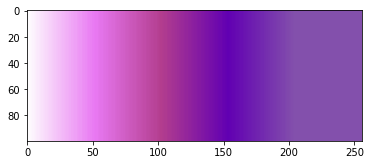

In [6]:
# https://coolors.co/ffffff-ea7af4-b43e8f-6200b3-8451ad
blueish_palette = A.parse_colors_co_scss('''
$color1: rgba(255, 255, 255, 1);
$color2: rgba(234, 122, 244, 1);
$color3: rgba(180, 62, 143, 1);
$color4: rgba(98, 0, 179, 1);
$color5: rgba(132, 81, 173, 1);
''')

cp = A.ColorPalette(colors=blueish_palette)

w, h = 256, 100
row = np.array([cp(value=v)['value'] for v in np.linspace(0, 1, w)])

plt.imshow(
np.array([
    row for y in range(h)
]));

In [7]:
settings.load_mapping().shape, settings.generate_mapping().shape

((600, 2), (1024, 2))

In [8]:
%pdb on

Automatic pdb calling has been turned ON


In [26]:
gd = A.GaussianDroplet(sigma=0, color=A.RGB(0, 0, 1), phi=np.pi / 100, theta=0)
gd()
# gd.signalparams

{'value': array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        ...,
        [0.00000000e+00, 0.00000000e+00, 1.59154943e+11],
        [0.00000000e+00, 0.00000000e+00, 1.59154943e+11],
        [0.00000000e+00, 0.00000000e+00, 1.59154943e+11]])}

In [24]:
%pdb off
rgb = A.RGB(1, 1, 1)
isinstance(rgb, A.L.Signal)

Automatic pdb calling has been turned OFF


False

In [17]:
hasattr(rgb, 'call')

True

# animated animations

In [7]:
import random
from matplotlib import animation, rc
from IPython.display import HTML

rc('animation', html='html5')

class MatplotlibAnimation:
    def __init__(self, xlim=[-1, 1], ylim=[-1, 1], frames=100, interval=20, figsize=(4, 4)):
        self.fig, self.ax = plt.subplots(figsize=figsize)
        self.ax.set_xlim(xlim)
        self.ax.set_ylim(ylim)
        self.line, = self.ax.plot([], [])
        self.frames, self.interval = frames, interval

    def init(self):
        self.line.set_data([], [])
        return self.line,

    def step(self, i):
        return self.line,

    def animate(self, frames=None, interval=None):
        if frames is None: frames = self.frames
        if interval is None: interval = self.interval
        return animation.FuncAnimation(
            self.fig, self.step, init_func=self.init, frames=frames, interval=interval, blit=True)

    def play(self, animation=None, **animate_kw):
        if animation is None:
            animation = self.animate(**animate_kw)
        plt.close(animation._fig)
        return HTML(animation.to_html5_video())

## stereo drone

In [8]:
class ArmDecay(MatplotlibAnimation):
    def __init__(self, values, n=100):
        super().__init__(xlim=(0, 1), ylim=(0, 1.1), frames=len(values), figsize=(12, 4))
        self.values = values
        self.n = n
        self.xs = np.linspace(0, 1, n)
        self.frames = len(values)
        
    def f(self, v):
        return v * (1 - self.xs)**4

    def step(self, i):
        self.line.set_data(self.xs, self.f(self.values[i]))
        return self.line,

ramp = np.concatenate([
    np.linspace(0, 1, 20),
    np.ones(3*20),
    np.linspace(1, 0, 20),
])

In [9]:
ArmDecay(ramp).play()

RuntimeError: Requested MovieWriter (ffmpeg) not available

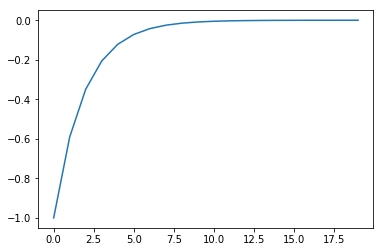

In [174]:
plt.plot(-np.exp(-np.linspace(0, 10, 20)))

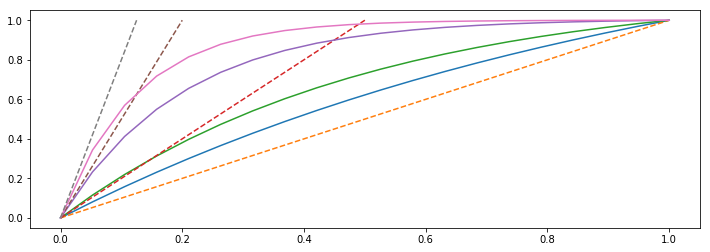

In [187]:
def decay(dx0, xs):
    """dx0 : initial steepness, xs : values 0..1"""
    ret = 1 - np.exp(-xs * dx0)
    return ret / ret[-1]

xs = np.linspace(0, 1, 20)
plt.figure(figsize=(12, 4))
for dx0 in (1, 2, 5, 8):
    plt.plot(xs, decay(dx0, xs))
    plt.plot([0, 1/dx0], [0, 1], '--')
# plt.plot(decay(2, xs))
# plt.plot(decay(4, xs))
# plt.plot(decay(8, xs))

In [170]:
class ArmImpulse(MatplotlibAnimation):
    def __init__(self, values, n=100):
        super().__init__(xlim=(0, 1), ylim=(0, 1.1), frames=len(values), figsize=(12, 4))
        self.values = values
        self.n = n
        self.xs = np.linspace(0, 1, n)
        self.frames = len(values)
        
    def f(self, v):
        return 1 * (np.abs(v - self.xs) < 0.02)

    def step(self, i):
        self.line.set_data(self.xs, self.f(self.values[i]))
        return self.line,

ramp = np.concatenate([
    np.linspace(0, 1, 40),
    np.ones(40),
])
ArmImpulse(ramp).play()

## chase

In [149]:

class RandomWalk(MatplotlibAnimation):
    def __init__(self):
        super().__init__()
        self.xs = []
        self.ys = []
        self.x = self.y = 0

    def step(self, i):
        self.x += random.random() * 0.2 - 0.1
        self.y += random.random() * 0.2 - 0.1
        self.xs.append(self.x)
        self.ys.append(self.y)
        self.line.set_data(self.xs, self.ys)
        return self.line,


class RandomWalkV(MatplotlibAnimation):
    def __init__(self):
        super().__init__()
        self.xs = []
        self.ys = []
        self.x = self.y = 0
        self.vx = self.vy = 0
    def step(self, i):
        self.vx += random.random() * 0.02 - 0.01
        self.vy += random.random() * 0.02 - 0.01
        self.x += self.vx
        self.y += self.vy
        if self.x < -1 or self.x > 1:
            self.x -= 2 * self.vx
            self.vx *= -1
        if self.y < -1 or self.y > 1:
            self.y -= 2 * self.vy
            self.vy *= -1
        self.xs.append(self.x)
        self.ys.append(self.y)
        self.line.set_data(self.xs, self.ys)
        return self.line,
    

class RandomWalkD(MatplotlibAnimation):
    def __init__(self):
        super().__init__()
        self.xs = []
        self.ys = []
        self.phi = 0
        self.x = self.y = 0
    def step(self, i):
        if self.x < -0.9 or self.x > 0.9:
            x, y = np.sin(self.phi), np.cos(self.phi)
            self.phi = np.arctan2(y, -x)
        if self.y < -0.9 or self.y > 0.9:
            x, y = np.sin(self.phi), np.cos(self.phi)
            self.phi = np.arctan2(-y, x)
        self.phi += (random.random() - 0.5) * np.pi / 5
        self.x += 0.1 * np.sin(self.phi)
        self.y += 0.1 * np.cos(self.phi)
        self.xs.append(self.x)
        self.ys.append(self.y)
        self.line.set_data(self.xs, self.ys)
        return self.line,

In [150]:
RandomWalkD().play(frames=100)

In [126]:
RandomWalkV().play(frames=300)

In [151]:
RandomWalk().play(frames=100)